# Global event discussion affects the travel destinations

In [2]:
import json
import pandas as pd

from langdetect import detect
import pycountry

import string
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import numpy as np

import seaborn as sns
from collections import OrderedDict
from datetime import datetime
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model
import math

import networkx as nx
import community as community_louvain
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict


In [34]:
reddit_token_df = pd.read_csv("Datasets/reddit_county_mentioned_token_df.csv")
youtube_token_df = pd.read_csv("Datasets/youtube_county_mentioned_token_df.csv")
display(reddit_token_df.head())
display(youtube_token_df.head())

,year,post_id,submission_tokens,comment_tokens,submission_countries,comment_countries
0,2025,1km2442,"['seek', 'firsttime', 'female', 'solo', 'trave...","['appear', 'request', 'personal', 'experience'...",['Italy'],"['Taiwan', 'Japan']"
1,2025,1km41dr,"['central', 'america', 'solo', 'backpack', 'tr...",[],"['Colombia', 'Belize', 'Nicaragua', 'Brazil', ...",[]
2,2025,1km4xdq,"['need', 'clarification', 'schengen', 'day', '...","['look', 'like', 'youre', 'plan', 'trip', 'aro...","['Turkey', 'France', 'Greece', 'Italy', 'Spain']",[]
3,2025,1km6iw5,"['try', 'find', 'beach', 'resort', 'recommenda...",[],"['Jamaica', 'Aruba', 'Bahamas', 'France']",[]
4,2025,1km6njw,"['book', 'first', 'international', 'solo', 'tr...","['note', 'ask', 'travel', 'advice', 'guatemala...","['Guatemala', 'Canada']",['Guatemala']


,year,video_id,comment_tokens,reply_tokens,comment_countries,reply_countries
0,2025,40W27HZCcso,"['amaze', 'content', 'im', 'go', 'bali', 'year...","['absolutely', 'hope', 'great', 'trip', 'thank...","['Singapore', 'Indonesia', 'Japan']",[]
1,2025,40W27HZCcso,"['amaze', 'content', 'im', 'go', 'bali', 'year...","['try', 'get', 'travel', 'guide', 'go', 'wish'...","['Singapore', 'Indonesia', 'Japan']",[]
2,2025,40W27HZCcso,"['video', 'stun', 'watch', 'anyone', 'feel', '...",[],[],[]
3,2025,40W27HZCcso,"['im', 'planning', 'visit', 'georgiamalaysiatu...","['thats', 'go', 'amazing', 'trip']","['Georgia', 'Malaysia', 'Turkey', 'Japan']",[]
4,2025,40W27HZCcso,"['happy', 'new', 'year', 'gonna', 'sick']","['cant', 'wait', 'see', 'get']",[],[]


In [35]:
reddit_token_df_wd = pd.read_csv("Datasets/reddit_county_mentioned_token_df_with_date.csv")
youtube_token_df_wd = pd.read_csv("Datasets/youtube_county_mentioned_token_df_with_date.csv")

In [36]:
# reshape reddit df
reddit_token_df["date"] = reddit_token_df_wd["date"]
youtube_token_df["date"] = youtube_token_df_wd["date"]
# for posts
reddit_sub_df = reddit_token_df[["year", "post_id", "submission_tokens", "submission_countries", "date"]].copy()
reddit_sub_df.columns = ["year", "id", "token", "countries", "date"]
reddit_sub_df["entry_type"] = "post"

# for comments
reddit_comment_df = reddit_token_df[["year", "post_id", "comment_tokens", "comment_countries", "date"]].copy()
reddit_comment_df.columns = ["year", "id", "token", "countries", "date"]
reddit_comment_df["entry_type"] = "comment"

# combine
reddit_token_df = pd.concat([reddit_sub_df, reddit_comment_df], ignore_index=True)
reddit_token_df["year"] = reddit_token_df["year"].astype(int)
reddit_token_df["platform"] = "reddit"
reddit_token_df = reddit_token_df[reddit_token_df["year"] >= 2018]

# reshape youtube df
# for reply
youtube_reply_df = youtube_token_df[["year", "video_id", "reply_tokens", "reply_countries", "date"]].copy()
youtube_reply_df.columns = ["year", "id", "token", "countries", "date"]
youtube_reply_df["entry_type"] = "reply"

# for comments
youtube_comment_df = youtube_token_df[["year", "video_id", "comment_tokens", "comment_countries", "date"]].copy()
youtube_comment_df.columns = ["year", "id", "token", "countries", "date"]
youtube_comment_df["entry_type"] = "comment"

# combine
youtube_token_df = pd.concat([youtube_comment_df, youtube_reply_df], ignore_index=True).drop_duplicates()
youtube_token_df["year"] = youtube_token_df["year"].astype(int)
youtube_token_df["platform"] = "youtube"
youtube_token_df = youtube_token_df[youtube_token_df["year"] >= 2018]

token_df = pd.concat([reddit_token_df, youtube_token_df], ignore_index=True)

display(token_df.head())

,year,id,token,countries,date,entry_type,platform
0,2025,1km2442,"['seek', 'firsttime', 'female', 'solo', 'trave...",['Italy'],2025-05-14,post,reddit
1,2025,1km41dr,"['central', 'america', 'solo', 'backpack', 'tr...","['Colombia', 'Belize', 'Nicaragua', 'Brazil', ...",2025-05-14,post,reddit
2,2025,1km4xdq,"['need', 'clarification', 'schengen', 'day', '...","['Turkey', 'France', 'Greece', 'Italy', 'Spain']",2025-05-14,post,reddit
3,2025,1km6iw5,"['try', 'find', 'beach', 'resort', 'recommenda...","['Jamaica', 'Aruba', 'Bahamas', 'France']",2025-05-14,post,reddit
4,2025,1km6njw,"['book', 'first', 'international', 'solo', 'tr...","['Guatemala', 'Canada']",2025-05-14,post,reddit


In [47]:
import ast
# convert strings to list
# convert strings to datetime
token_df["token"] = token_df["token"].apply(ast.literal_eval)
token_df["countries"] = token_df["countries"].apply(ast.literal_eval)
token_df["date"] = pd.to_datetime(token_df["date"])

reddit_token_df["token"] = reddit_token_df["token"].apply(ast.literal_eval)
reddit_token_df["countries"] = reddit_token_df["countries"].apply(ast.literal_eval)
reddit_token_df["date"] = pd.to_datetime(token_df["date"])

youtube_token_df["token"] = youtube_token_df["token"].apply(ast.literal_eval)
youtube_token_df["countries"] = youtube_token_df["countries"].apply(ast.literal_eval)
youtube_token_df["date"] = pd.to_datetime(token_df["date"])

Text(0, 0.5, 'Count')

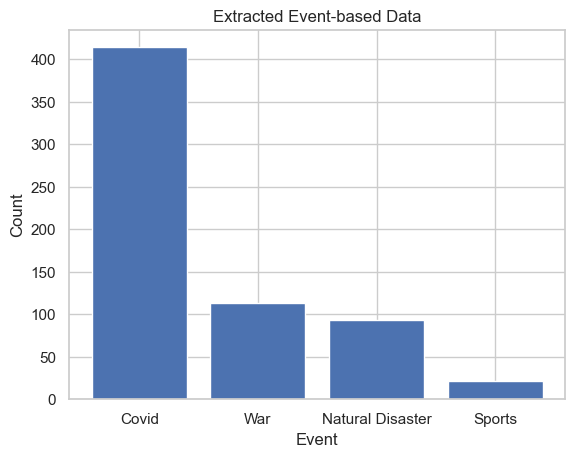

In [ ]:
# 3xtract events
event_keywords = {
    "Covid": ["covid", "covid19", "coronavirus", "corona", "pandemic", "lockdown", "vaccine", "virus", "quarantine", "vaccinate",
              "mask", "epidemic"],
    "Sports": ["olympic", "paralympic","summer games", "winter games", "seoul2018","tokyo2020", "beijing2022", "paris2024", 
                 "torch relay", "opening ceremony", "world cup", "fifa", "worldcup", "qatar2022", "russia2018"],
    "Natural Disaster": ["earthquake", "bushfire", "wildfire", "tsunami", "hurricane", "cyclone", "storm", "flood",
                         "typhoon"],
    "War": ["war","invasion"]
}

def contains_phrase(tokens, phrase):
    phrase_tokens = phrase.lower().split()
    for i in range(len(tokens) - len(phrase_tokens) + 1):
        if tokens[i:i+len(phrase_tokens)] == phrase_tokens:
            return True
    return False

def tag_event(tokens):
    for event, keywords in event_keywords.items():
        tokens = [token.lower() for token in tokens]
        for keyword in keywords:
            if ' ' in keyword:
                # phrase match
                if contains_phrase(tokens, keyword):
                    return event
            else:
                # single token match
                if keyword in tokens:
                    return event
    return None

token_df["event"] = token_df["token"].apply(tag_event)

event_count = token_df["event"].value_counts()

plt.bar(event_count.index, event_count.values)
plt.title("Extracted Event-based Data")
plt.xlabel("Event")
plt.ylabel("Count")

In [49]:
reddit_token_df['event'] = reddit_token_df["token"].apply(tag_event)
youtube_token_df['event'] = youtube_token_df["token"].apply(tag_event)

In [ ]:
# event counts
reddit_token_df['event'].value_counts()

Covid               370
War                  91
Natural Disaster     89
Sports               21
Name: event, dtype: int64

In [ ]:
# data subset for events
covid_token_df = token_df[token_df["event"]=="Covid"]

nd_token_df = token_df[token_df["event"]=="Natural Disaster"]

sports_token_df = token_df[(token_df["event"]=="Sports")]

war_token_df = token_df[token_df["event"] == "War"]

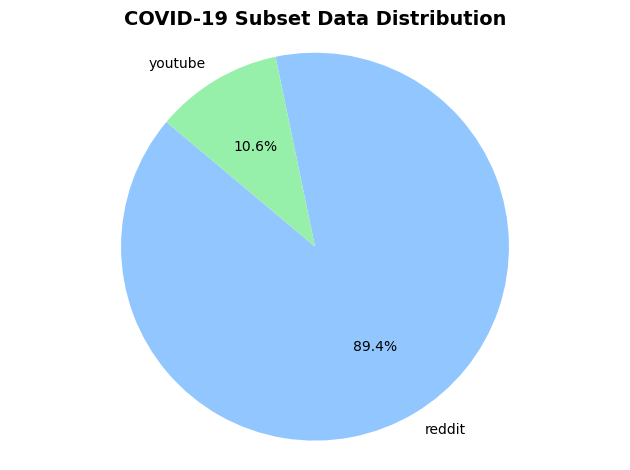

In [ ]:
# covid19 subset distribution
covid_platform_data_count = covid_token_df['platform'].value_counts()
plt.pie(covid_platform_data_count, labels=covid_platform_data_count.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title("COVID-19 Subset Data Distribution", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

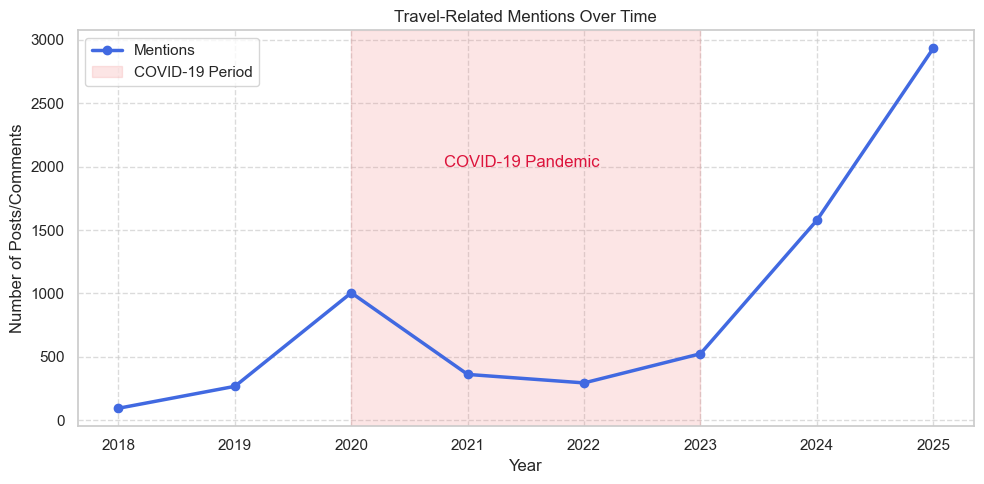

In [ ]:
# data count over time
volume_df = token_df.groupby("year").size().reset_index(name="mentions")
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
plt.plot(volume_df["year"], volume_df["mentions"], marker='o', linewidth=2.5, color='royalblue', label='Mentions')
plt.axvspan(2020, 2023, color='lightcoral', alpha=0.2, label='COVID-19 Period')
plt.text(2021-0.2, 2000,
         "COVID-19 Pandemic", fontsize=12, color='crimson')

plt.title("Travel-Related Mentions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Posts/Comments")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## Sentiment Analysis

In [13]:
def vaderPrintTokens(tokens, score, label):
    print(f"\n{label.upper()}:")
    print(", ".join(tokens))
    for k, v in score.items():
        print(f"{k}: {v}", end=", ")
    print()

def vaderSentimentAnalysis(df, print_output=False):
    """
    Performs VADER sentiment analysis on each row of the dataframe.

    @param df: A DataFrame with columns ['year', 'token', 'countries', 'entry_type']
    @param print_output: Whether to print token-level sentiment output

    @returns: A new DataFrame with ['year', 'country', 'tokens', 'entry_type', 'sentiment_score']
    """
    sentAnalyser = SentimentIntensityAnalyzer()
    sentiment = []

    for _, row in df.iterrows():
        year = row['year']
        tokens = row['token']
        countries = row['countries']
        date = row['date']
        entry_type = row['entry_type']
        event = row['event']

        text = " ".join(tokens)
        dSentimentScores = sentAnalyser.polarity_scores(text)
        
        if print_output:
            vaderPrintTokens(tokens, dSentimentScores, entry_type)

        if countries:
            for country in countries:
                sentiment.append({
                    "year": year,
                    "date": date,
                    "country": country,
                    "tokens": tokens,
                    "entry_type": entry_type,
                    "sentiment_score": dSentimentScores['compound'],
                    "event": event
                })
        else:
            sentiment.append({
                "year": year,
                "date": date,
                "country": None,
                "tokens": tokens,
                "entry_type": entry_type,
                "sentiment_score": dSentimentScores['compound'],
                "event": event
            })

    return pd.DataFrame(sentiment)


In [53]:
sentiment = vaderSentimentAnalysis(token_df)

In [ ]:
reddit_sentiment = vaderSentimentAnalysis(reddit_token_df)
youtube_sentiment = vaderSentimentAnalysis(youtube_token_df)

# avg sentiment of country 
country_reddit_sentiment = reddit_sentiment.groupby(by=['country', 'year'])['sentiment_score'].mean().reset_index()
country_youtube_sentiment = youtube_sentiment.groupby(by=['country', 'year'])['sentiment_score'].mean().reset_index()

In [ ]:
# sentiment label
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

sentiment["sentiment_label"] = sentiment["sentiment_score"].apply(classify_sentiment)

### Sentiment By Event

In [56]:
sentiment['tokens_str'] = sentiment['tokens'].apply(lambda x: " ".join(x))
sentiment_dist = sentiment.drop_duplicates(subset=['year', 'tokens_str'])

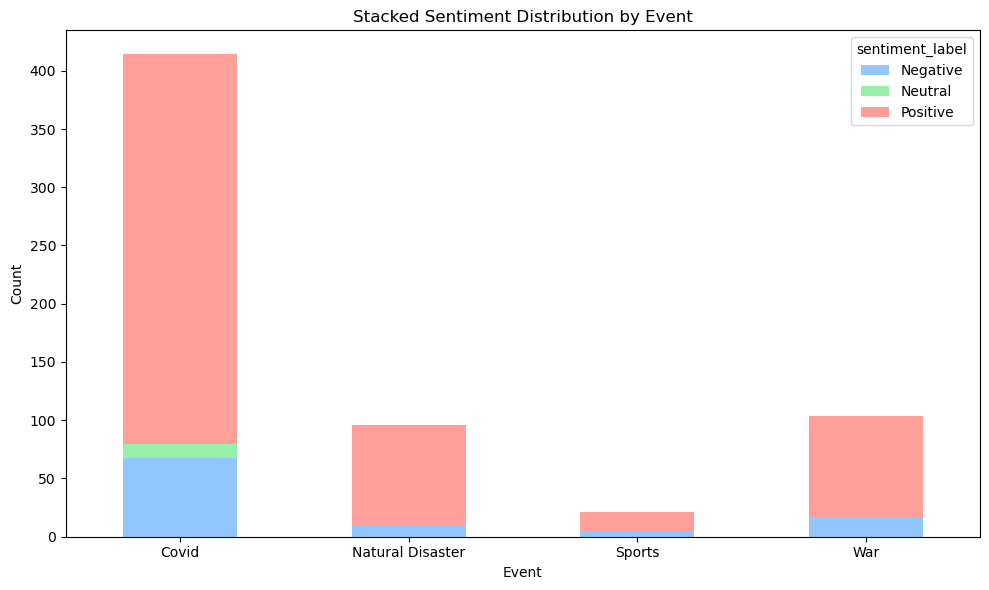

In [ ]:

grouped_sentiment = sentiment_dist.groupby(['event', 'sentiment_label']).size().unstack(fill_value=0)

grouped_sentiment.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title("Stacked Sentiment Distribution by Event")
plt.xlabel("Event")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Sentiment By Countries

### Sentiment Trends (Global Sport Events)

C:\Users\User\AppData\Local\Temp\ipykernel_5972\1863205526.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sports_sentiment['date'] = pd.to_datetime(sports_sentiment['date'])
C:\Users\User\AppData\Local\Temp\ipykernel_5972\1863205526.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sports_sentiment['year'] = sports_sentiment['date'].dt.year
C:\Users\User\AppData\Local\Temp\ipykernel_5972\1863205526.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

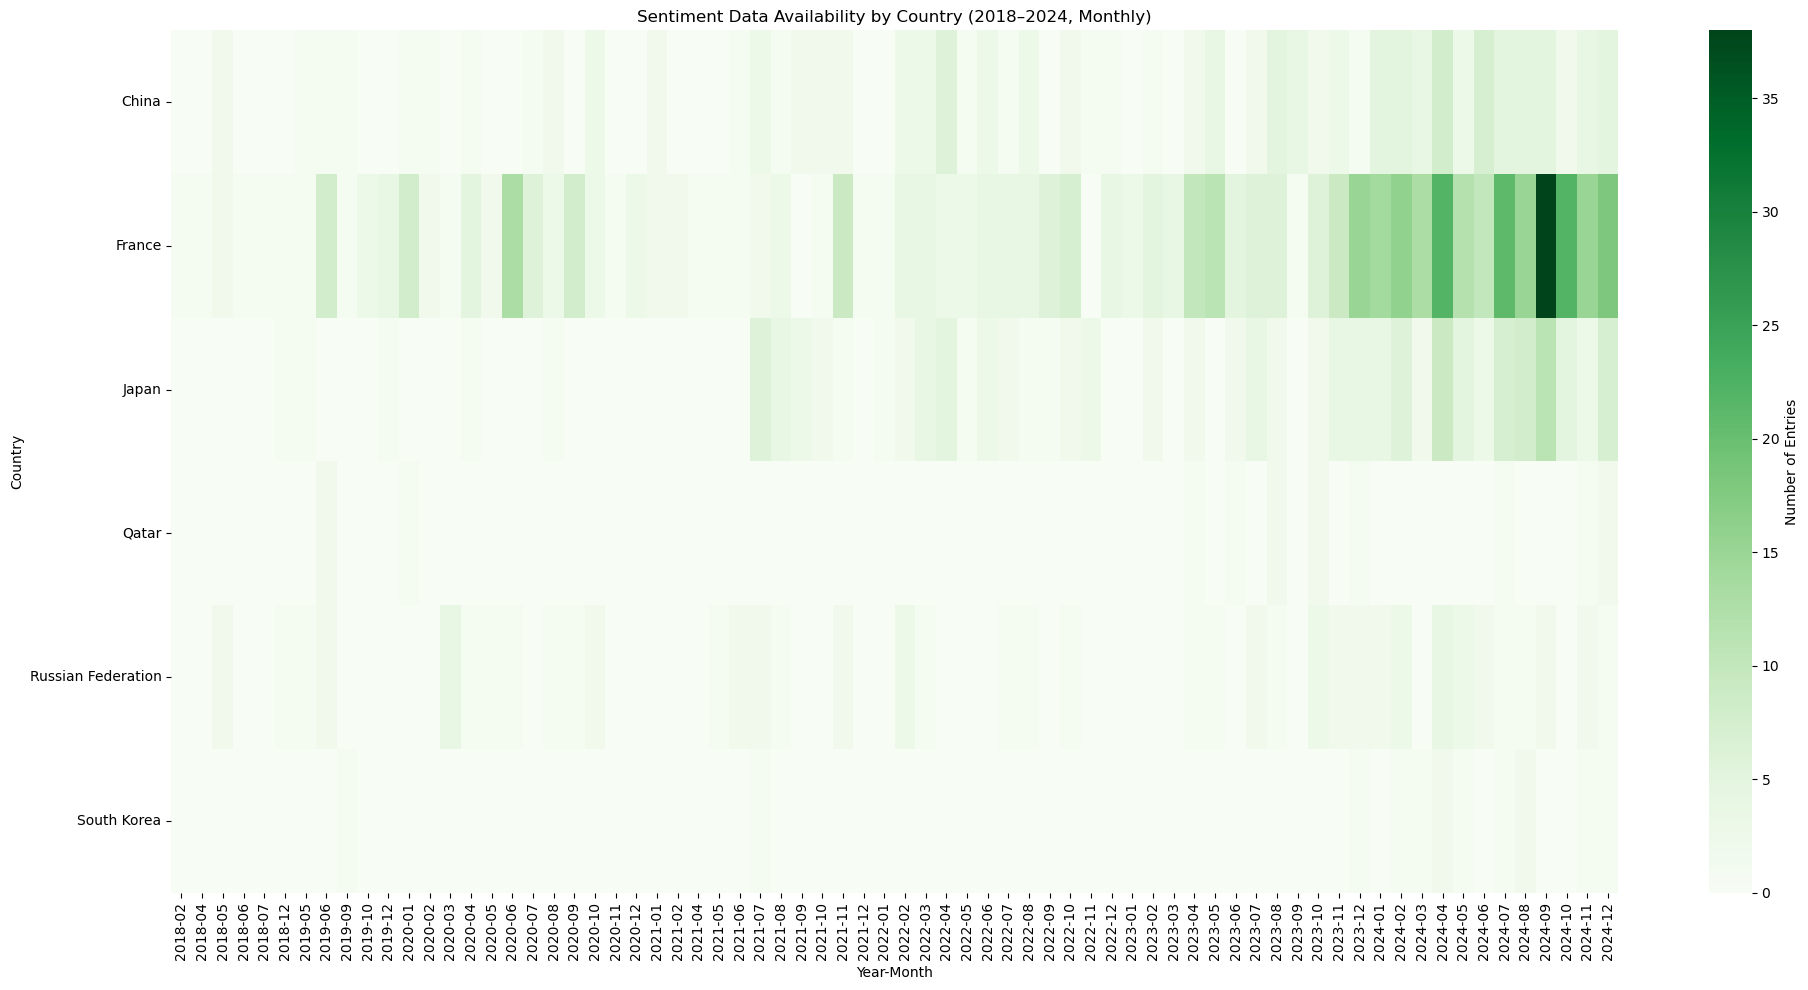

In [ ]:
# data availability for sports event countries
sports_country = ["France", "China", "Qatar", "Japan", "Russian Federation", "South Korea"]
sports_sentiment = sentiment[sentiment['country'].isin(sports_country)]

sports_sentiment['date'] = pd.to_datetime(sports_sentiment['date'])
sports_sentiment['year'] = sports_sentiment['date'].dt.year
sports_sentiment['month'] = sports_sentiment['date'].dt.month

filtered_sports = sports_sentiment[(sports_sentiment['year'] >= 2018) & (sports_sentiment['year'] <= 2024)].copy()

# Create a 'year-month' column for clarity
filtered_sports['year_month'] = filtered_sports['date'].dt.to_period('M').astype(str)
filtered_sports['available'] = 1

# Pivot table: rows = countries, columns = year-month, values = entry count
heatmap_data = filtered_sports.pivot_table(
    index='country',
    columns='year_month',
    values='available',
    aggfunc='count',
    fill_value=0
)

# Drop countries with no data at all
heatmap_data = heatmap_data[heatmap_data.sum(axis=1) > 0]

# Sort columns (time-wise)
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

# Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_data, cmap='Greens', cbar_kws={'label': 'Number of Entries'})
plt.title("Sentiment Data Availability by Country (2018–2024, Monthly)")
plt.xlabel("Year-Month")
plt.ylabel("Country")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

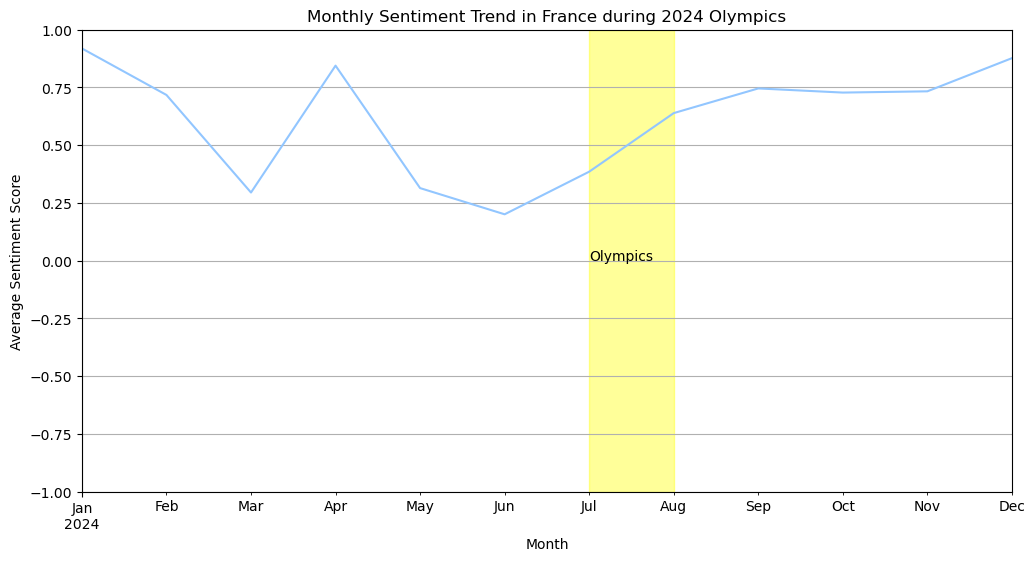

In [59]:
host_country = "France"
olympic_year = 2024
olympic_start = pd.to_datetime("2024-07-26").date()
olympic_end = pd.to_datetime("2024-08-11").date()

# Filter for just the Olympic year
sports_event_df = sentiment[
    (sentiment["country"] == host_country) &
    (sentiment["year"] == olympic_year)
].copy()

plt.figure(figsize=(12,6))
sports_event_df.set_index("date", inplace=True)
avg = sports_event_df["sentiment_score"].resample("M").mean()
avg.plot()
plt.axvspan(olympic_start, olympic_end, color='yellow', alpha=0.4, label="Olympics")
plt.text(olympic_start, 0, "Olympics", fontsize=10, color="black")
plt.title(f"Monthly Sentiment Trend in {host_country} during {olympic_year} Olympics")
plt.xlabel("Month")
plt.ylabel("Average Sentiment Score")
plt.ylim(-1, 1)
plt.grid(True)
plt.show()

### Sentiment Trends (COVID-19 Pandemic)

C:\Users\User\AppData\Local\Temp\ipykernel_5972\1215784268.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-pastel")  # Try "ggplot", "fivethirtyeight", "seaborn", etc.


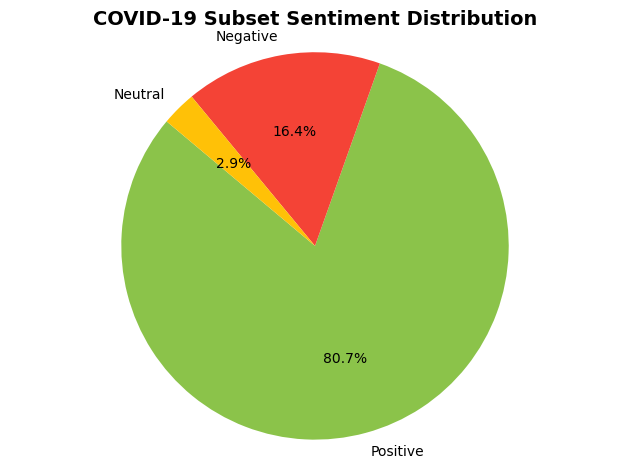

In [ ]:
covid_sentiment = sentiment[sentiment["event"]=="Covid"]
covid_sentiment_dist = covid_sentiment.drop_duplicates(['tokens'])
label_counts = covid_sentiment_dist["sentiment_label"].value_counts()

plt.style.use("seaborn-pastel")  

# Count sentiment labels
label_counts = covid_sentiment_dist["sentiment_label"].value_counts()
labels = label_counts.index
sizes = label_counts.values
colors = ['#8BC34A', '#F44336', '#FFC107'] 

plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.axis('equal')
plt.title("COVID-19 Subset Sentiment Distribution", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_5972\2442222699.py:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-pastel")


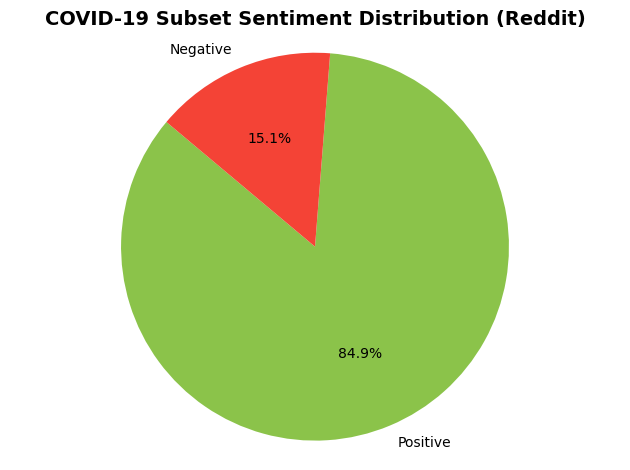

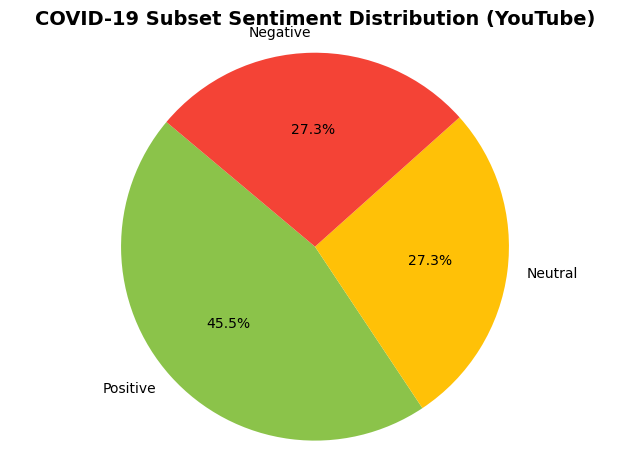

In [61]:
reddit_sentiment["sentiment_label"] = reddit_sentiment["sentiment_score"].apply(classify_sentiment)
youtube_sentiment["sentiment_label"] = youtube_sentiment["sentiment_score"].apply(classify_sentiment)

covid_reddit_sentiment = reddit_sentiment[reddit_sentiment["event"]=="Covid"]
covid_youtube_sentiment = youtube_sentiment[youtube_sentiment["event"]=="Covid"]

covid_reddit_sentiment_dist = covid_reddit_sentiment.drop_duplicates(['tokens'])
covid_youtube_sentiment_dist = covid_youtube_sentiment.drop_duplicates(['tokens'])

label_counts_reddit = covid_reddit_sentiment_dist["sentiment_label"].value_counts()
label_counts_youtube = covid_youtube_sentiment_dist["sentiment_label"].value_counts()

plt.style.use("seaborn-pastel")

# Count sentiment labels
label_counts = covid_reddit_sentiment_dist["sentiment_label"].value_counts()
labels = label_counts.index
sizes = label_counts.values
colors = ['#8BC34A', '#F44336','#FFC107'] 
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.axis('equal')
plt.title("COVID-19 Subset Sentiment Distribution (Reddit)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

label_counts = covid_youtube_sentiment_dist["sentiment_label"].value_counts()
labels = label_counts.index
sizes = label_counts.values
colors = ['#8BC34A', '#FFC107', '#F44336'] 
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.axis('equal')
plt.title("COVID-19 Subset Sentiment Distribution (YouTube)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_5972\1398899578.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-pastel")


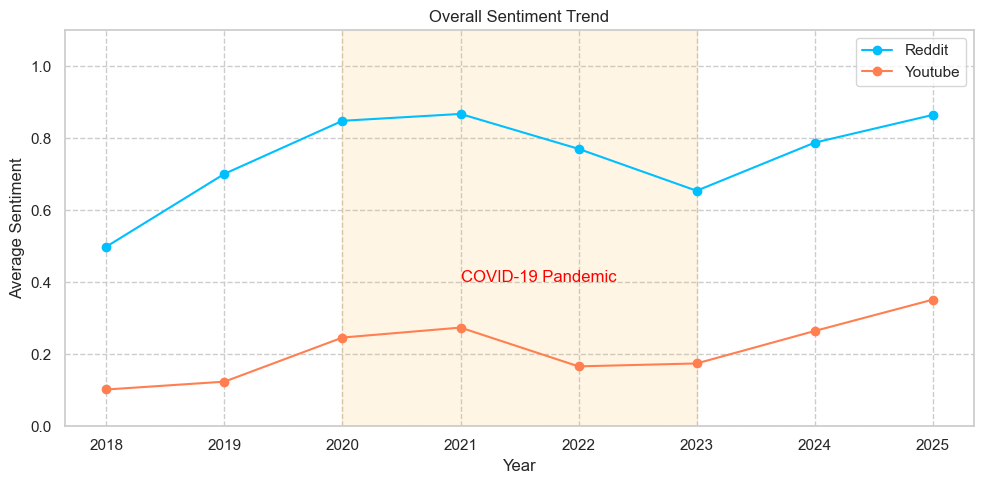

In [ ]:
# overall sentiment trend
overall_youtube_sentiment = youtube_sentiment.groupby(by="year")["sentiment_score"].mean().reset_index()
overall_reddit_sentiment = reddit_sentiment.groupby(by="year")["sentiment_score"].mean().reset_index()

plt.style.use("seaborn-pastel")
plt.figure(figsize=(10, 5))
plt.plot(overall_reddit_sentiment["year"], overall_reddit_sentiment["sentiment_score"], marker="o", label="Reddit", color="deepskyblue")
plt.plot(overall_youtube_sentiment["year"], overall_youtube_sentiment["sentiment_score"], marker="o", label = "Youtube", color="coral")
plt.axvspan(2020, 2023, color='orange', alpha=0.1)
plt.text(2021, 0.4 , "COVID-19 Pandemic", fontsize=12, color="red")
plt.title("Overall Sentiment Trend")
plt.xlabel("Year")
plt.ylabel("Average Sentiment")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [62]:
covid_countries = ["China", "United States", "India", "France", "Germany", "Brazil", "South Korea", "Japan", "Italy", "United Kingdom", "Turkey", "Australia"]
covid_reddit_df = country_reddit_sentiment[country_reddit_sentiment["country"].isin(covid_countries)].copy()
covid_reddit_df = covid_reddit_df.sort_values(by=["country", "year"])

covid_youtube_df = country_youtube_sentiment[country_youtube_sentiment["country"].isin(covid_countries)].copy()
covid_youtube_df = covid_youtube_df.sort_values(by=["country", "year"])

display(covid_reddit_df.head())
display(covid_youtube_df.head())

,country,year,sentiment_score
42,Australia,2018,1.000000
43,Australia,2019,1.000000
44,Australia,2020,0.712371
45,Australia,2021,0.999450
46,Australia,2022,0.713479


,country,year,sentiment_score
17,Australia,2019,0.868800
18,Australia,2020,0.149100
19,Australia,2023,-0.063640
20,Australia,2024,0.570300
21,Australia,2025,0.571084


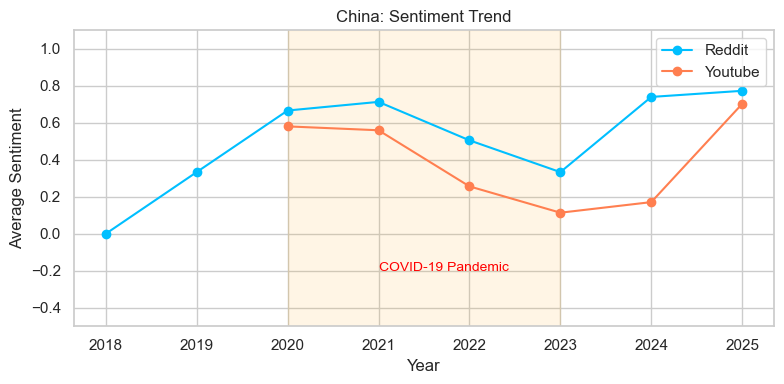

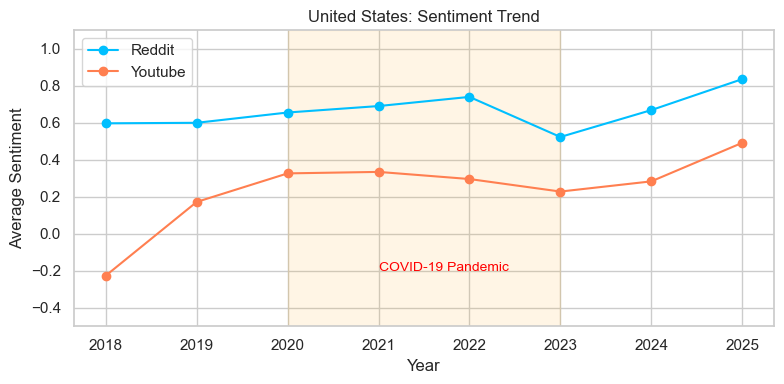

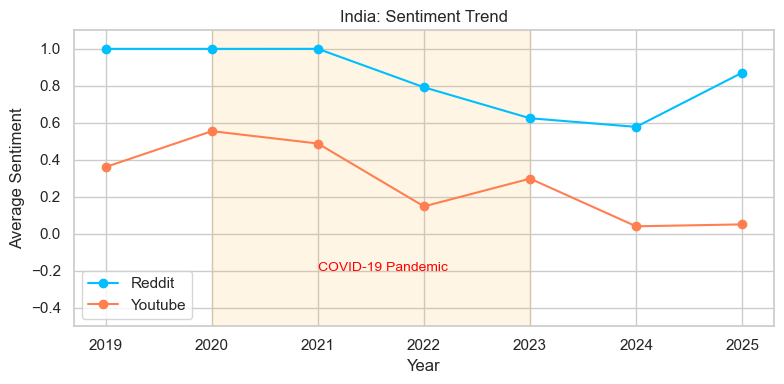

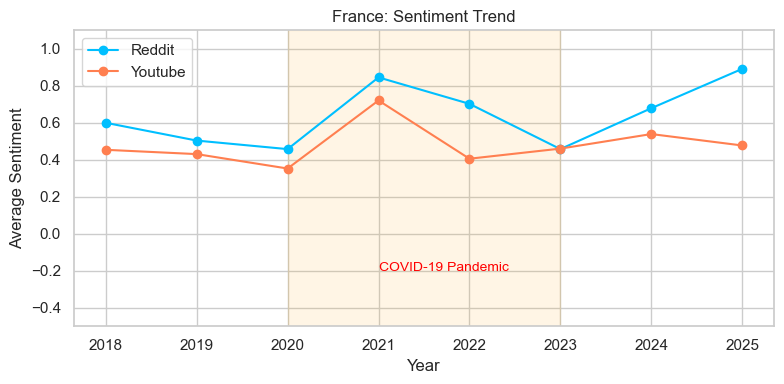

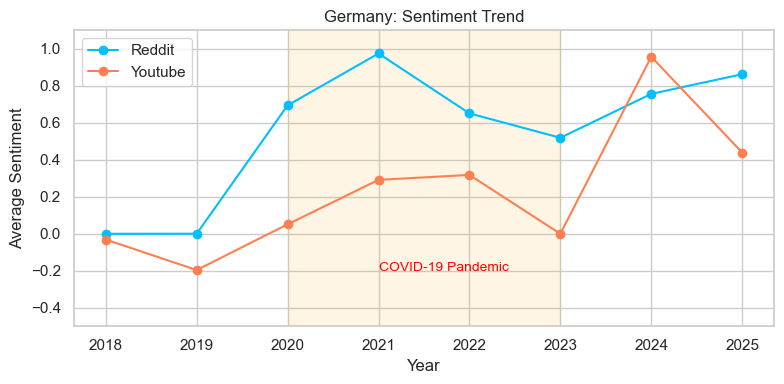

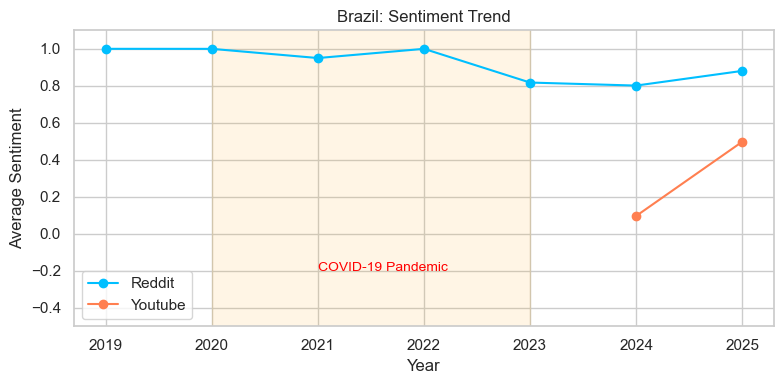

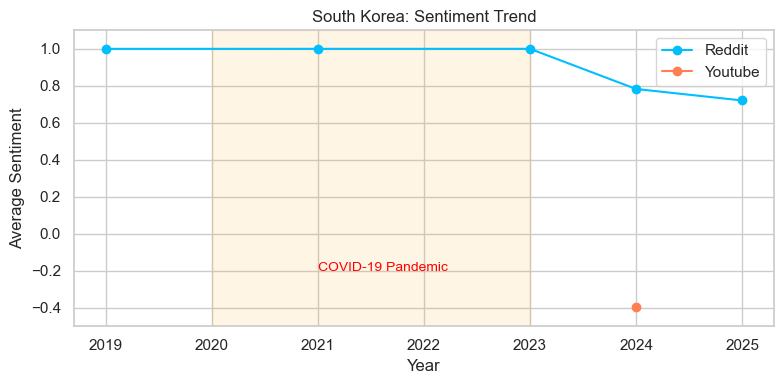

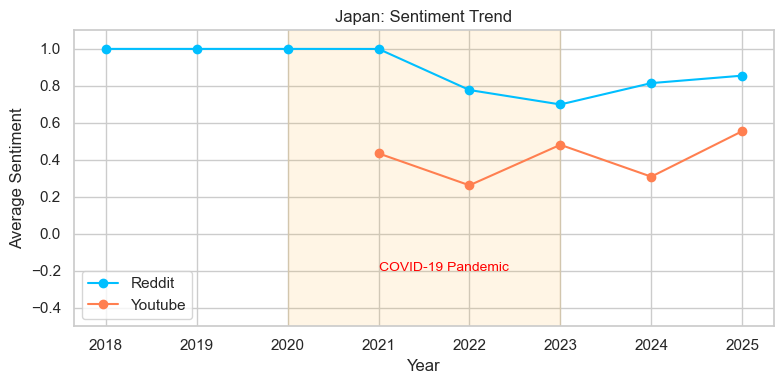

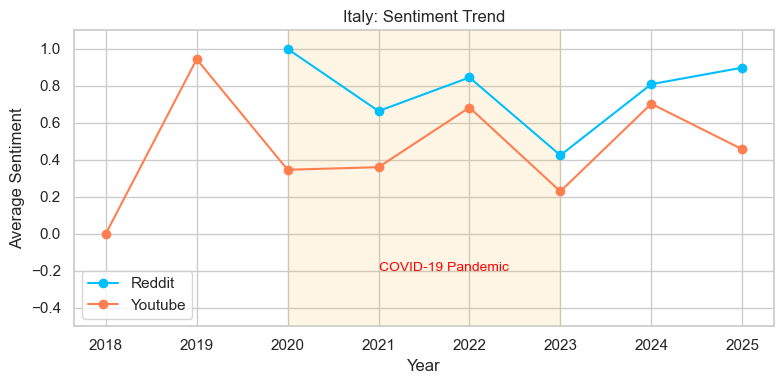

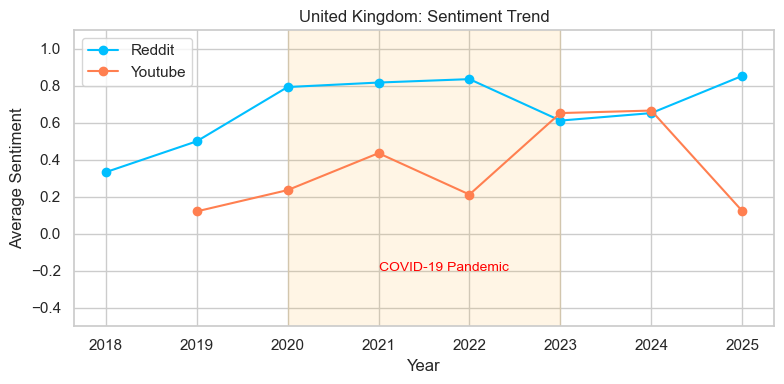

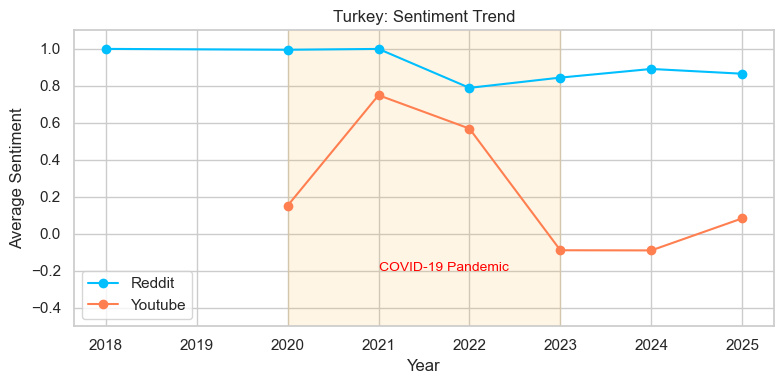

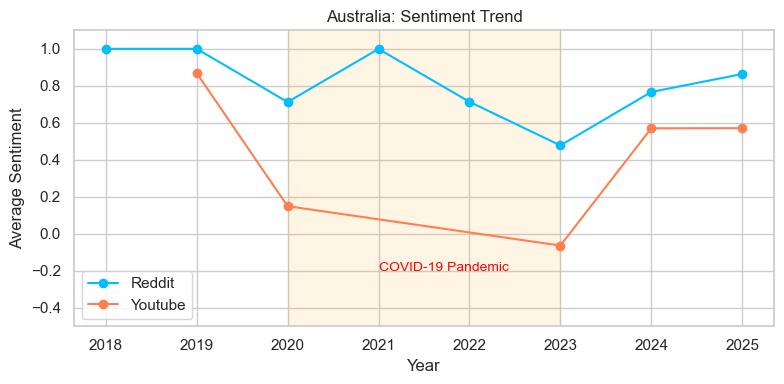

In [177]:
# Create one plot per country
for country in covid_countries:
    country_df_r = covid_reddit_df[covid_reddit_df["country"] == country]
    country_df_yt = covid_youtube_df[covid_youtube_df["country"] == country]

    plt.figure(figsize=(8, 4))
    plt.plot(country_df_r["year"], country_df_r["sentiment_score"], marker="o", label="Reddit", color="deepskyblue")
    plt.plot(country_df_yt["year"], country_df_yt["sentiment_score"], marker="o", label = "Youtube", color="coral")
    plt.axvspan(2020, 2023, color='orange', alpha=0.1)
    plt.text(2021, -0.2 , "COVID-19 Pandemic", fontsize=10, color="red")
    plt.title(f"{country}: Sentiment Trend")
    plt.xlabel("Year")
    plt.ylabel("Average Sentiment")
    plt.ylim(-0.5, 1.1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Topic Modeling

In [75]:
tokens = []
source = []

for _, row in covid_token_df.iterrows():
    tokens.append(' '.join(row["token"]))
    source.append((row["platform"], row["entry_type"], row["id"]))  # Or index

In [76]:
topicNum = 3
wordNumToDisplay = 20
featureNum = 2000

# Count vectorizer
tfVectorizer = CountVectorizer(max_df=0.70, min_df=3, max_features=featureNum, stop_words='english')
tf = tfVectorizer.fit_transform(tokens)
tfFeatureNames = tfVectorizer.get_feature_names_out()

# LDA model
ldaModel = LatentDirichletAllocation(
    n_components=topicNum,
    max_iter=10,
    learning_method='online',
    random_state=42
)
ldaModel.fit(tf)

LatentDirichletAllocation(learning_method='online', n_components=3,
                          random_state=42)

In [77]:
def display_topics(model, featureNames, numTopWords):
    """
    Prints out the most associated words for each feature.

    @param model: lda model.
    @param featureNames: list of strings, representing the list of features/words.
    @param numTopWords: number of words to print per topic.
    """

    # print out the topic distributions
    for topicId, lTopicDist in enumerate(model.components_):
        print("Topic %d:" % (topicId))
        print(" ".join([featureNames[i] for i in lTopicDist.argsort()[:-numTopWords - 1:-1]]))

display_topics(ldaModel, tfFeatureNames, wordNumToDisplay)

Topic 0:
travel job money trip american solo state cost high meet america tax city safe europe problem school issue trump government
Topic 1:
food city japan trip tourist india culture nice travel south walk american lol indian area guy eat state local movie
Topic 2:
kid parent nta child shes mom relationship oop husband woman care brother hope sister baby dad fuck mother partner situation


In [78]:
panel = pyLDAvis.lda_model.prepare(ldaModel, tf, tfVectorizer, mds='tsne')
pyLDAvis.display(panel)

c:\Users\User\anaconda3\lib\site-packages\pyLDAvis\_prepare.py:243: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(


In [79]:
def displayWordcloud(model, featureNames):
    """
    Displays the word cloud of the topic distributions, stored in model.

    @param model: lda model.
    @param featureNames: list of strings, representing the list of features/words.
    """

    normalisedComponents = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    
    topicNum = len(model.components_)

    plotColNum = 3

    plotRowNum = int(math.ceil(topicNum / plotColNum))
    plt.figure(figsize=(15,10))
    for topicId, lTopicDist in enumerate(normalisedComponents):
        lWordProb = {featureNames[i] : wordProb for i,wordProb in enumerate(lTopicDist)}
        wordcloud = WordCloud(background_color='white')
        wordcloud.fit_words(frequencies=lWordProb)
        plt.subplot(plotRowNum, plotColNum, topicId+1)
        plt.title('Topic %d:' % (topicId+1))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")

    plt.show(block=True)

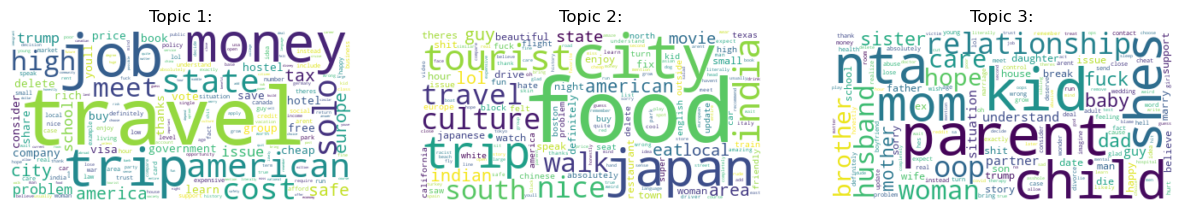

In [80]:
displayWordcloud(ldaModel, tfFeatureNames)

In [81]:
tf_matrix = tfVectorizer.transform(tokens)

topic_distributions = ldaModel.transform(tf_matrix)

dominant_topics = np.argmax(topic_distributions, axis=1)

In [82]:
topic_df = pd.DataFrame({
    "platform": [meta[0] for meta in source],
    "type": [meta[1] for meta in source],
    "id": [meta[2] for meta in source],
    "topic": dominant_topics,
    "text": tokens
})

In [83]:
topic_df[(topic_df["topic"]==1) & (topic_df["platform"]=="reddit")& (topic_df["type"]=="post")]

,platform,type,id,topic,text
0,reddit,post,1khziv2,1,spain trip itinerary check madrid barcelona an...
4,reddit,post,1kfohpf,1,forget yellow fever pas hi go bolivia chile tw...
6,reddit,post,1kakqys,1,drab city heart gold story thats bratislava ev...
7,reddit,post,1jyrv0h,1,trip report volcano hike guatemala 26f first s...
8,reddit,post,1jvulsx,1,trip report 10d solo trip verona venice bologn...
11,reddit,post,1jlg6uh,1,colombia tayrona park itinerary help currently...
15,reddit,post,szksev,1,soon become tenth person dog become first dog ...
16,reddit,post,lb1x84,1,best city visit italy im 18f solo travel u wan...
22,reddit,post,g8grqa,1,walk around world dog ama five year ago leave ...
27,reddit,post,1ivka2w,1,best place visit uk hello im half french canad...


In [ ]:
# manual check
with open('Datasets/combined_unique_reddit_posts.json', 'r') as file:
    raw_data = json.load(file)

raw_data = list(raw_data['submissions'])

post_id_to_search = "1jidgsx"
[post for post in raw_data if post["id"] == post_id_to_search]

[{'id': '1jidgsx',
  'title': 'Thailand and Vietnam in May/June',
  'selftext': 'Hello all! I am planning a trip to Thailand, Cambodia, Vietnam, and Hong Kong, and just wanted to get some feedback. It’s my first trip longer than two weeks, and I’m struggling a little with making sure I’ve allocated appropriate time per place. Hoping to get some feedback before booking transit. \n\nDays 1-3: Fly into Phuket, will probably spend the first two days taking it easy. Plan to do a boat excursion. \n\nDays 4-6: ferry or bus to Krabi. Plan to do some excursions like kayaking in the mangroves, another boat tour. \n\nDays 7-10: fly from Krabi to Chiang Mai. Plan to do some nature stuff like hikes, and an elephant sanctuary. Sleeper train to Bangkok at the end of day 10. \n\nDays 10-13: Bangkok. Plan to see some of the sights in the city. \n\nDays 14-16: either flying or taking a bus to Siem Reap. Mostly just here for Angkor Wat and surrounding temples, to be honest. Overnight bus night of day 16.

### Keyword Trend Analysis

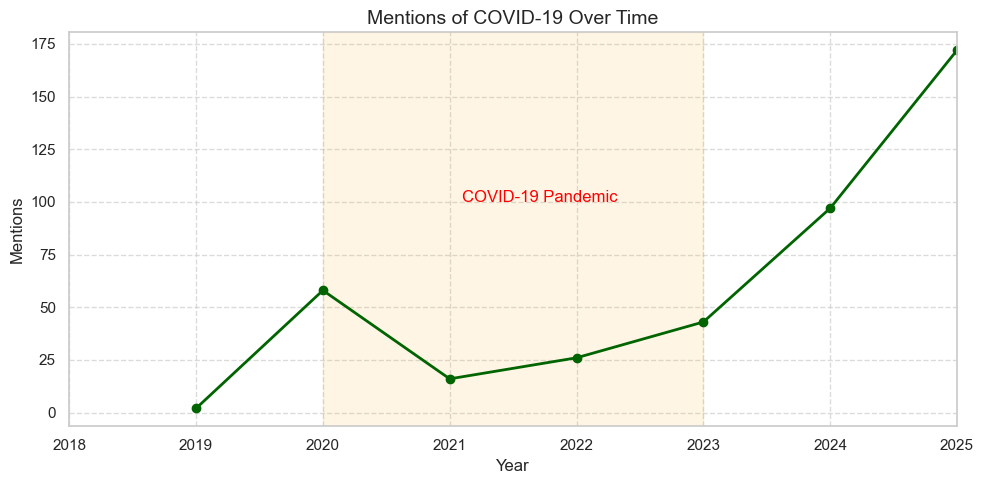

In [189]:
keywords = ["covid", "covid19", "coronavirus", "corona", "pandemic", "lockdown", "vaccine", "virus", "quarantine", "vaccinate",
              "mask", "epidemic"]
keyword_trend = defaultdict(int)

# Loop through each row once
for i, row in token_df.iterrows():
    tokens = [t.lower() for t in row['token']]
    if any(keyword in tokens for keyword in keywords):
        keyword_trend[row['year']] += 1

# Create DataFrame outside the loop
trend_df = pd.DataFrame(list(keyword_trend.items()), columns=['year', 'count']).sort_values('year')

# Plotting
plt.figure(figsize=(10, 5))
plt.axvspan(2020, 2023, color='orange', alpha=0.1)
plt.text(2021+0.1, 100, "COVID-19 Pandemic", fontsize=12, color="red")
plt.plot(trend_df['year'], trend_df['count'], marker='o', color='darkgreen', linewidth=2)
plt.title("Mentions of COVID-19 Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mentions", fontsize=12)
plt.xlim(2018, 2025)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

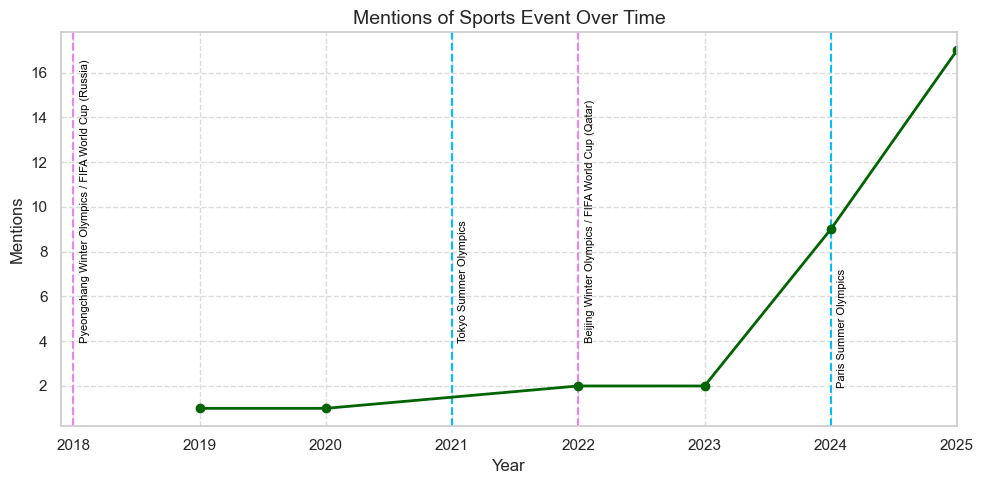

In [185]:
keywords = ["olympic", "paralympic","summer games", "winter games", "seoul2018","tokyo2020", "beijing2022", "paris2024", 
                 "torch relay", "opening ceremony", "world cup", "fifa", "worldcup", "qatar2022", "russia2018"]
keyword_trend = defaultdict(int)

# Loop through each row once
for i, row in token_df.iterrows():
    tokens = [t.lower() for t in row['token']]
    if any(keyword in tokens for keyword in keywords):
        keyword_trend[row['year']] += 1

# Create DataFrame outside the loop
trend_df = pd.DataFrame(list(keyword_trend.items()), columns=['year', 'count']).sort_values('year')

# Plotting
plt.figure(figsize=(10, 5))
plt.axvline(x=2018, color='violet', linestyle='--')
plt.text(2018 + 0.05, 4, "Pyeongchang Winter Olympics / FIFA World Cup (Russia)", rotation=90, fontsize=8, color="black")
plt.axvline(x=2021, color='deepskyblue', linestyle='--')
plt.text(2021 + 0.05, 4, "Tokyo Summer Olympics", rotation=90, fontsize=8, color="black")
plt.axvline(x=2022, color='violet', linestyle='--')
plt.text(2022 + 0.05, 4, "Beijing Winter Olympics / FIFA World Cup (Qatar)", rotation=90, fontsize=8, color="black")
plt.axvline(x=2024, color='deepskyblue', linestyle='--')
plt.text(2024 + 0.05, 2, "Paris Summer Olympics", rotation=90, fontsize=8, color="black")
plt.title("Mentions of Sports Event Over Time", fontsize=14)
plt.plot(trend_df['year'], trend_df['count'], marker='o', color='darkgreen', linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mentions", fontsize=12)
plt.xlim(2018-0.1, 2025)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

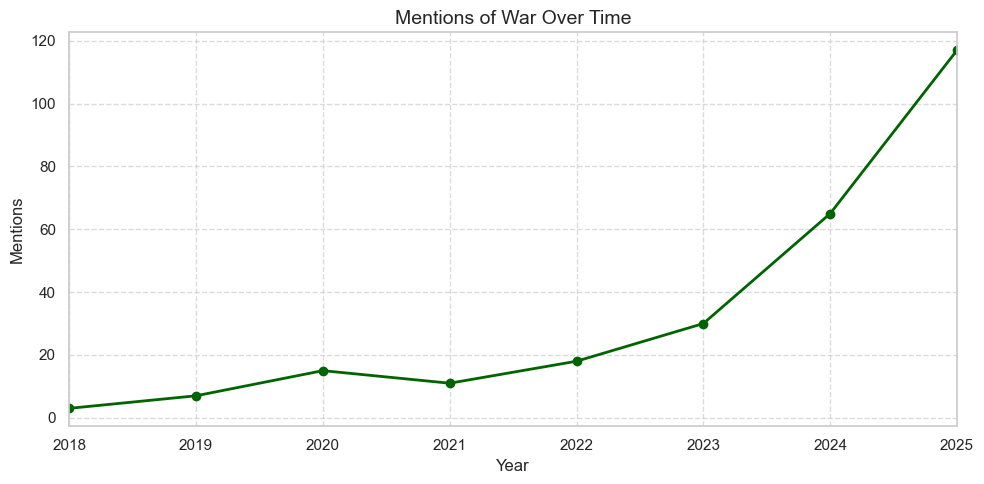

In [148]:
keywords = ["war", "invasion"]
keyword_trend = defaultdict(int)

# Loop through each row once
for i, row in token_df.iterrows():
    tokens = [t.lower() for t in row['token']]
    if any(keyword in tokens for keyword in keywords):
        keyword_trend[row['year']] += 1

# Create DataFrame outside the loop
trend_df = pd.DataFrame(list(keyword_trend.items()), columns=['year', 'count']).sort_values('year')

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(trend_df['year'], trend_df['count'], marker='o', color='darkgreen', linewidth=2)
plt.title("Mentions of War Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mentions", fontsize=12)
plt.xlim(2018, 2025)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

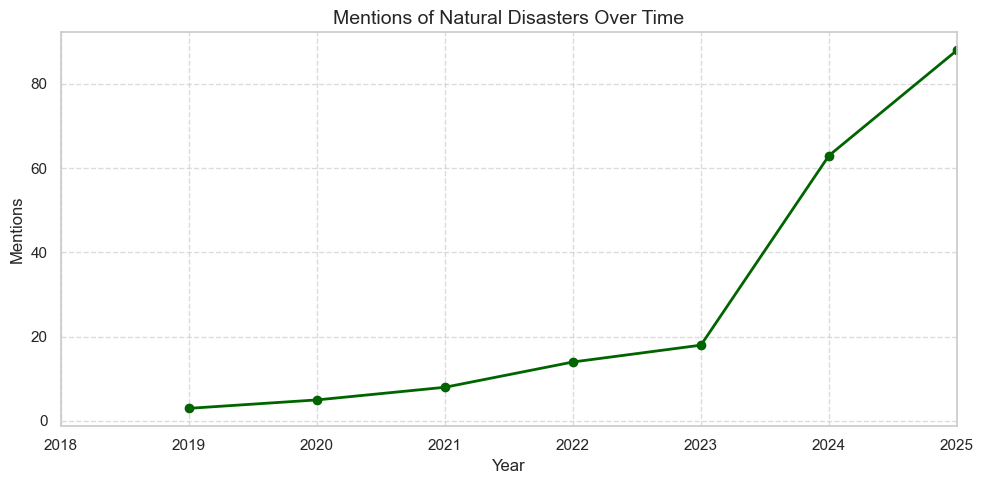

In [150]:
keywords = ["earthquake", "bushfire", "wildfire", "tsunami", "hurricane", "cyclone", "storm", "flood",
                         "typhoon"]
keyword_trend = defaultdict(int)

# Loop through each row once
for i, row in token_df.iterrows():
    tokens = [t.lower() for t in row['token']]
    if any(keyword in tokens for keyword in keywords):
        keyword_trend[row['year']] += 1

# Create DataFrame outside the loop
trend_df = pd.DataFrame(list(keyword_trend.items()), columns=['year', 'count']).sort_values('year')

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(trend_df['year'], trend_df['count'], marker='o', color='darkgreen', linewidth=2)
plt.title("Mentions of Natural Disasters Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mentions", fontsize=12)
plt.xlim(2018, 2025)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()